# 09 — H1: Portfolio Sorts on Employee Sentiment

**Goal:** Test whether firms with higher lagged employee sentiment earn higher
stock returns. Forms quintile portfolios sorted on prior-year sentiment and
compares their returns. This is the raw-return test; risk-adjustment (alpha)
follows in notebook 10.

**Input:** `data/panel_monthly.parquet` (membership-filtered as of 2026-07-02;
see `docs/membership_fix_memo_2026-07-02.md`)

**Output:**
- `data/long_short_returns.parquet` — monthly long-short portfolio return series,
  full 2013–2024 window (feeds the alpha regression in notebook 10, which
  applies the 2013–2023 headline restriction itself)

**Method (pre-committed specification):**
- Each year, sort firms into quintiles by lagged sentiment
- Equal-weighted portfolios, annual rebalancing
- Q5 = highest sentiment, Q1 = lowest sentiment
- Long-short = Q5 − Q1

**Reporting note (2026-07-02):** headline raw long-short statistics are
reported on 2013–2023 (132 months) to match the thesis window; full-window
stats remain for the 2024 robustness footnote.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

DATA_PROCESSED = Path.home() / "thesis" / "data"
OUTPUT = Path.home() / "thesis" / "output"

panel = pd.read_parquet(DATA_PROCESSED / "panel_monthly.parquet")
print(f"Panel: {len(panel):,} firm-months, {panel['gvkey'].nunique()} firms")
print(f"Year range: {panel['year'].min()} to {panel['year'].max()}")

# We need: gvkey, year, month, ret, sentiment_overall_lag
# Drop rows missing return or sentiment (should be few since panel is already filtered)
panel = panel.dropna(subset=["ret", "sentiment_overall_lag"]).copy()
print(f"After dropping missing ret/sentiment: {len(panel):,} firm-months")

Panel: 65,291 firm-months, 636 firms
Year range: 2013 to 2024
After dropping missing ret/sentiment: 65,275 firm-months


In [2]:
# For each year, assign each firm to a sentiment quintile based on lagged sentiment.
# Because sentiment is constant within a firm-year (same lagged value for all 12 months),
# we sort on the firm-year level first, then apply to all months.

# Get one sentiment value per firm-year
firm_year_sentiment = (
    panel.groupby(["gvkey", "year"])["sentiment_overall_lag"]
    .first()
    .reset_index()
)

# Assign quintiles within each year (1 = lowest sentiment, 5 = highest)
firm_year_sentiment["quintile"] = (
    firm_year_sentiment.groupby("year")["sentiment_overall_lag"]
    .transform(lambda x: pd.qcut(x, q=5, labels=[1, 2, 3, 4, 5]))
)

# Check the assignment
print("Firms per quintile per year (should be ~equal within each year):")
print(firm_year_sentiment.groupby(["year", "quintile"]).size().unstack())
print()

# Verify sentiment increases monotonically across quintiles
print("Mean sentiment by quintile (should increase 1→5):")
print(firm_year_sentiment.groupby("quintile")["sentiment_overall_lag"].mean().round(3))

Firms per quintile per year (should be ~equal within each year):
quintile   1   2   3   4   5
year                        
2013      83  83  84  81  83
2014      84  85  83  84  84
2015      86  86  85  86  86
2016      90  89  90  89  90
2017      90  90  90  90  90
2018      92  92  91  92  92
2019      93  93  92  95  91
2020      94  93  93  93  93
2021      95  94  94  94  94
2022      96  95  95  95  95
2023      95  95  95  95  95
2024      96  94  94  95  95

Mean sentiment by quintile (should increase 1→5):
quintile
1    2.907
2     3.34
3    3.541
4    3.726
5     4.07
Name: sentiment_overall_lag, dtype: Float64


/var/folders/2j/hjkjj6xd441624gv0_y769_w0000gn/T/ipykernel_31355/3082744801.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(firm_year_sentiment.groupby(["year", "quintile"]).size().unstack())
/var/folders/2j/hjkjj6xd441624gv0_y769_w0000gn/T/ipykernel_31355/3082744801.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(firm_year_sentiment.groupby("quintile")["sentiment_overall_lag"].mean().round(3))


In [3]:
# Merge quintile assignments back to the monthly panel
panel_q = panel.merge(
    firm_year_sentiment[["gvkey", "year", "quintile"]],
    on=["gvkey", "year"],
    how="left"
)

# Equal-weighted portfolio return = simple mean of constituent firm returns,
# computed per quintile per month
portfolio_returns = (
    panel_q.groupby(["year", "month", "quintile"], observed=True)["ret"]
    .mean()
    .reset_index()
    .rename(columns={"ret": "portfolio_ret"})
)

# Create a proper date column for time-series work
portfolio_returns["date"] = pd.to_datetime(
    portfolio_returns["year"].astype(str) + "-" +
    portfolio_returns["month"].astype(str) + "-01"
) + pd.offsets.MonthEnd(0)

print(f"Portfolio-month observations: {len(portfolio_returns)}")
print(f"  (should be ~12 months × 12 years × 5 quintiles = 720)")
print()

# Mean monthly return by quintile across the full sample
print("Mean MONTHLY return by sentiment quintile:")
mean_by_q = portfolio_returns.groupby("quintile", observed=True)["portfolio_ret"].mean()
print((mean_by_q * 100).round(3).astype(str) + "%")
print()

# Annualize for interpretability (compound monthly to annual)
print("Annualized return by sentiment quintile:")
annualized = (1 + mean_by_q) ** 12 - 1
print((annualized * 100).round(2).astype(str) + "%")

Portfolio-month observations: 720
  (should be ~12 months × 12 years × 5 quintiles = 720)

Mean MONTHLY return by sentiment quintile:
quintile
1    1.083%
2    1.239%
3    1.217%
4    1.272%
5    1.235%
Name: portfolio_ret, dtype: object

Annualized return by sentiment quintile:
quintile
1     13.8%
2    15.92%
3    15.62%
4    16.39%
5    15.87%
Name: portfolio_ret, dtype: object


In [4]:
from scipy import stats

# Pivot to get each quintile's monthly return in its own column
pivot = portfolio_returns.pivot(index="date", columns="quintile", values="portfolio_ret")
pivot.columns = [f"Q{int(c)}" for c in pivot.columns]

# Long-short: Q5 minus Q1
pivot["long_short"] = pivot["Q5"] - pivot["Q1"]

print("Long-short (Q5 - Q1) monthly return statistics:")
ls = pivot["long_short"].dropna()
print(f"  Mean monthly return: {ls.mean()*100:.4f}%")
print(f"  Annualized:          {((1+ls.mean())**12 - 1)*100:.2f}%")
print(f"  Std (monthly):       {ls.std()*100:.4f}%")
print(f"  Months:              {len(ls)}")
print()

# t-test: is the long-short mean different from zero?
t_stat, p_value = stats.ttest_1samp(ls, 0)
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value:     {p_value:.3f}")
print(f"  Significant at 5%? {'Yes' if p_value < 0.05 else 'No'}")
print()

# Sharpe ratio of the long-short (annualized)
sharpe = (ls.mean() / ls.std()) * np.sqrt(12)
print(f"  Annualized Sharpe ratio: {sharpe:.3f}")

# Save the long-short series for the alpha regression in notebook 10
ls_out = pivot[["long_short", "Q1", "Q5"]].reset_index()
ls_out.to_parquet(DATA_PROCESSED / "long_short_returns.parquet", index=False)
print(f"\nSaved long-short return series to long_short_returns.parquet")

Long-short (Q5 - Q1) monthly return statistics:
  Mean monthly return: 0.1514%
  Annualized:          1.83%
  Std (monthly):       1.6682%
  Months:              144

  t-statistic: 1.089
  p-value:     0.278
  Significant at 5%? No

  Annualized Sharpe ratio: 0.314

Saved long-short return series to long_short_returns.parquet


In [5]:
# HEADLINE WINDOW (added 2026-07-02): the thesis reports the raw long-short
# on 2013-2023; the 2024 extension is robustness only. The saved parquet
# keeps the full 2013-2024 series (notebook 10 applies its own restriction).
ls_headline = pivot.loc[pivot.index.year <= 2023, "long_short"].dropna()
t_hl, p_hl = stats.ttest_1samp(ls_headline, 0)
print("Headline window 2013-2023 (raw long-short):")
print(f"  Mean monthly return: {ls_headline.mean()*100:.4f}%")
print(f"  Std (monthly):       {ls_headline.std()*100:.4f}%")
print(f"  Months:              {len(ls_headline)}")
print(f"  t-statistic:         {t_hl:.3f}")
print(f"  p-value:             {p_hl:.3f}")

Headline window 2013-2023 (raw long-short):
  Mean monthly return: 0.1498%
  Std (monthly):       1.6478%
  Months:              132
  t-statistic:         1.044
  p-value:             0.298


In [6]:
# VALUE-WEIGHTED long-short (added 2026-07-14 after external review; a post-hoc
# robustness check, NOT part of the pre-committed battery, and labeled as such
# in the thesis). Weights: prior-month market equity, matched on calendar month
# via merge (never a positional shift -- membership gaps would misalign it).
# panel_monthly starts 2013-01, so the first weighted month is 2013-02 (N = 131).
vw = panel_q[["gvkey", "year", "month", "quintile", "ret", "me"]].copy()
vw["ym"] = vw["year"] * 12 + vw["month"]
_prev_me = vw[["gvkey", "ym", "me"]].copy()
_prev_me["ym"] = _prev_me["ym"] + 1
vw = vw.merge(_prev_me.rename(columns={"me": "me_lag"}), on=["gvkey", "ym"],
              how="left", validate="m:1")
vw_ok = vw.dropna(subset=["me_lag", "ret", "quintile"]).copy()
vw_ok["rw"] = vw_ok["ret"].astype("float64") * vw_ok["me_lag"].astype("float64")
_g = vw_ok.groupby(["year", "month", "quintile"], observed=True)[["rw", "me_lag"]].sum()
vw_ret = (_g["rw"] / _g["me_lag"]).reset_index(name="portfolio_ret")
vw_ret["date"] = pd.to_datetime(
    vw_ret["year"].astype(str) + "-" + vw_ret["month"].astype(str) + "-01"
) + pd.offsets.MonthEnd(0)
pivot_vw = vw_ret.pivot(index="date", columns="quintile", values="portfolio_ret")
pivot_vw.columns = [f"Q{int(c)}" for c in pivot_vw.columns]
pivot_vw["long_short_vw"] = pivot_vw["Q5"] - pivot_vw["Q1"]

ls_vw_hl = pivot_vw.loc[pivot_vw.index.year <= 2023, "long_short_vw"].dropna()
t_vw, p_vw = stats.ttest_1samp(ls_vw_hl, 0)
print("VALUE-WEIGHTED long-short, headline window 2013-2023:")
print(f"  Mean monthly return: {ls_vw_hl.mean()*100:.4f}%")
print(f"  t-statistic:         {t_vw:.2f}   (p = {p_vw:.3f}, N = {len(ls_vw_hl)})")

pivot_vw[["long_short_vw"]].reset_index().to_parquet(
    DATA_PROCESSED / "long_short_returns_vw.parquet", index=False)
print("\nSaved long_short_returns_vw.parquet (full series; notebook 10 restricts).")

VALUE-WEIGHTED long-short, headline window 2013-2023:
  Mean monthly return: 0.4508%
  t-statistic:         1.90   (p = 0.059, N = 131)

Saved long_short_returns_vw.parquet (full series; notebook 10 restricts).


In [7]:
# VALUE-WEIGHTED CONCENTRATION DIAGNOSTIC (added 2026-08-06; post-hoc, same
# status as the value-weighted check above, and labeled as such in the thesis).
# Boustanifar & Kang (2022) discount their own value-weighted Best Companies
# alpha because "a few mega-cap stocks dominate the value-weighted portfolio".
# This measures whether the same concentration holds here. The weights are
# exactly those used above -- prior-month market equity within each
# quintile-month -- so these shares describe the portfolio actually reported.
conc = vw_ok.loc[vw_ok["year"] <= 2023, ["year", "month", "quintile", "me_lag"]].copy()
conc["me_lag"] = conc["me_lag"].astype("float64")


def _shares(g):
    w = (g / g.sum()).sort_values(ascending=False)
    return pd.Series({
        "n": float(len(w)),
        "top1": w.iloc[0],
        "top3": w.head(3).sum(),
        "top10": w.head(10).sum(),
        "hhi": (w ** 2).sum(),
    })


shares = (conc.groupby(["quintile", "year", "month"], observed=True)["me_lag"]
              .apply(_shares).unstack())

print("Weight concentration of the value-weighted legs, 2013-2023")
print("(mean across the 131 weighted months; equal weighting shown for reference)\n")
for q in (5, 1):
    s = shares.loc[q].mean()
    n = s["n"]
    leg = "long" if q == 5 else "short"
    print(f"  Q{q} ({leg} leg, mean n = {n:.0f} firms):")
    print(f"     top 1 holding  {s['top1']*100:5.1f}%   (equal-weighted: {100/n:4.1f}%)")
    print(f"     top 3          {s['top3']*100:5.1f}%   (equal-weighted: {300/n:4.1f}%)")
    print(f"     top 10         {s['top10']*100:5.1f}%   (equal-weighted: {1000/n:4.1f}%)")
    print(f"     HHI            {s['hhi']:.4f}   (equal-weighted: {1/n:.4f})")
    print()

# Year by year: is the concentration stable, or does it build over the window?
by_year = shares.loc[5].groupby("year")[["top1", "top3", "top10", "hhi"]].mean()
print("Q5 (long leg) concentration by year, percent of portfolio weight:")
print((by_year[["top1", "top3", "top10"]] * 100).round(1).to_string())

by_year.to_csv(OUTPUT / "table_vw_concentration.csv")
print("\nSaved table_vw_concentration.csv")

Weight concentration of the value-weighted legs, 2013-2023
(mean across the 131 weighted months; equal weighting shown for reference)

  Q5 (long leg, mean n = 90 firms):
     top 1 holding   14.6%   (equal-weighted:  1.1%)
     top 3           31.9%   (equal-weighted:  3.3%)
     top 10          56.1%   (equal-weighted: 11.1%)
     HHI            0.0540   (equal-weighted: 0.0111)

  Q1 (short leg, mean n = 90 firms):
     top 1 holding    8.4%   (equal-weighted:  1.1%)
     top 3           19.4%   (equal-weighted:  3.3%)
     top 10          40.1%   (equal-weighted: 11.1%)
     HHI            0.0269   (equal-weighted: 0.0111)

Q5 (long leg) concentration by year, percent of portfolio weight:
      top1  top3  top10
year                   
2013  12.0  26.5   53.2
2014  12.5  25.9   49.9
2015  14.5  28.2   55.3
2016   9.5  22.8   51.4
2017  12.0  26.7   54.8
2018  13.7  31.5   56.9
2019  13.6  32.3   57.1
2020  17.0  38.0   59.3
2021  17.5  38.6   58.2
2022  20.7  41.7   61.3
2023  17.7

In [8]:
# Per-year long-short return — is the null consistent or does it mask volatility?
yearly_ls = portfolio_returns.pivot_table(
    index="year", columns="quintile", values="portfolio_ret", aggfunc="mean", observed=True
)
yearly_ls.columns = [f"Q{int(c)}" for c in yearly_ls.columns]
yearly_ls["LS (Q5-Q1)"] = yearly_ls["Q5"] - yearly_ls["Q1"]

print("Average monthly long-short return BY YEAR:")
print((yearly_ls[["LS (Q5-Q1)"]] * 100).round(3).astype(str) + "%")
print()
print(f"Years with positive LS: {(yearly_ls['LS (Q5-Q1)'] > 0).sum()} / {len(yearly_ls)}")

Average monthly long-short return BY YEAR:
     LS (Q5-Q1)
year           
2013     0.074%
2014    -0.171%
2015    -0.257%
2016     0.325%
2017     0.565%
2018     0.298%
2019     0.269%
2020     0.456%
2021    -0.157%
2022     -0.65%
2023     0.896%
2024     0.169%

Years with positive LS: 8 / 12


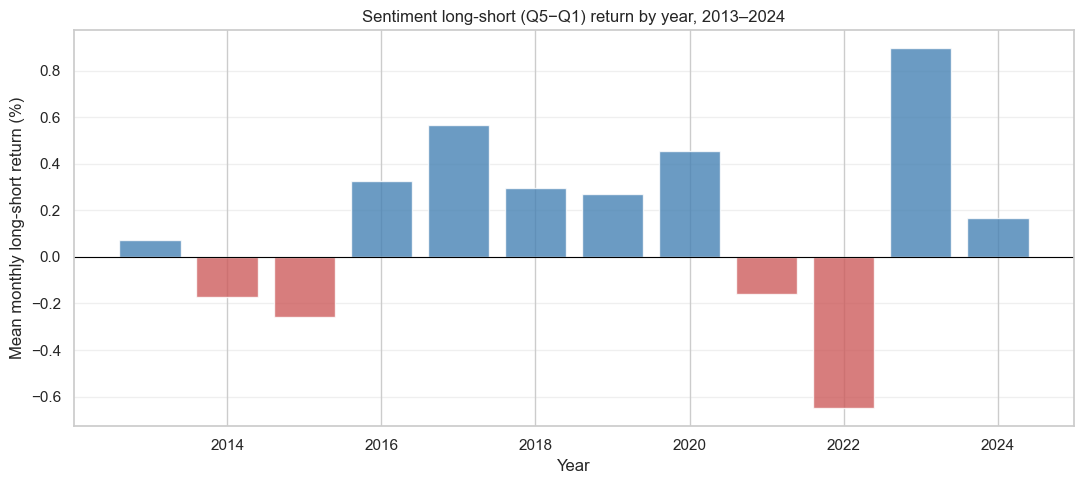

Saved figure.


In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
colors = ["steelblue" if x > 0 else "indianred" for x in yearly_ls["LS (Q5-Q1)"]]
ax.bar(yearly_ls.index, yearly_ls["LS (Q5-Q1)"] * 100, color=colors, alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Mean monthly long-short return (%)")
ax.set_title("Sentiment long-short (Q5−Q1) return by year, 2013–2024")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(OUTPUT / "fig_long_short_by_year.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved figure.")